# Stage 1 — Data Refinement

## Цель
Подготовить очищенный, воспроизводимый и расширенный датасет для обучения классификатора интентов.

## Задачи этапа
- собрать базовый Stage 1 dataset;
- проверить exact duplicates и конфликтные тексты;
- провести анализ near-duplicates и suspicious cross-class pairs;
- выполнить ручную ревизию пограничных примеров;
- очистить датасет;
- пересобрать clean train/val/test;
- добавить hard-negatives только в train;
- выполнить аугментацию только train до 500+ примеров на класс.

In [2]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

BASE_DIR = Path("..").resolve()

stage0_dataset = BASE_DIR / "data/processed/full_dataset.csv"
stage1_base = BASE_DIR / "data/processed/full_dataset_stage1_base.csv"
stage1_clean = BASE_DIR / "data/processed/full_dataset_stage1_clean.csv"

train_clean = BASE_DIR / "data/splits/stage1/train_clean.csv"
val_path = BASE_DIR / "data/splits/stage1/val.csv"
test_path = BASE_DIR / "data/splits/stage1/test.csv"
train_with_hn = BASE_DIR / "data/splits/stage1/train_with_hard_negatives.csv"
train_aug = BASE_DIR / "data/splits/stage1/train_augmented.csv"
train_aug_only = BASE_DIR / "data/splits/stage1/train_augmented_only.csv"

review_dir = BASE_DIR / "data/interim/review"
reports_dir = BASE_DIR / "logs/reports"

In [3]:
df_stage0 = pd.read_csv(stage0_dataset)
df_stage1_base = pd.read_csv(stage1_base)
df_stage1_clean = pd.read_csv(stage1_clean)

df_train_clean = pd.read_csv(train_clean)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)
df_train_with_hn = pd.read_csv(train_with_hn)
df_train_aug = pd.read_csv(train_aug)
df_train_aug_only = pd.read_csv(train_aug_only)

print("stage0:", df_stage0.shape)
print("stage1_base:", df_stage1_base.shape)
print("stage1_clean:", df_stage1_clean.shape)
print("train_clean:", df_train_clean.shape)
print("val:", df_val.shape)
print("test:", df_test.shape)
print("train_with_hn:", df_train_with_hn.shape)
print("train_aug:", df_train_aug.shape)
print("train_aug_only:", df_train_aug_only.shape)

stage0: (3038, 5)
stage1_base: (3038, 9)
stage1_clean: (3025, 10)
train_clean: (2117, 10)
val: (454, 10)
test: (454, 10)
train_with_hn: (2142, 14)
train_aug: (5200, 15)
train_aug_only: (3058, 15)


## Распределение классов до и после ручной ревизии

In [4]:
dist_before = df_stage1_base["label"].value_counts().sort_index()
dist_after = df_stage1_clean["label"].value_counts().sort_index()

comparison = pd.DataFrame({
    "before_clean": dist_before,
    "after_clean": dist_after
}).fillna(0).astype(int)

comparison["delta"] = comparison["after_clean"] - comparison["before_clean"]
comparison

,before_clean,after_clean,delta
label,,,
account,307,307,0
delivery,306,306,0
general_info,297,296,-1
order_status,326,326,0
other,305,305,0
payment_refund,307,310,3
product_info,315,313,-2
promo_loyalty,279,279,0
return_exchange,306,293,-13


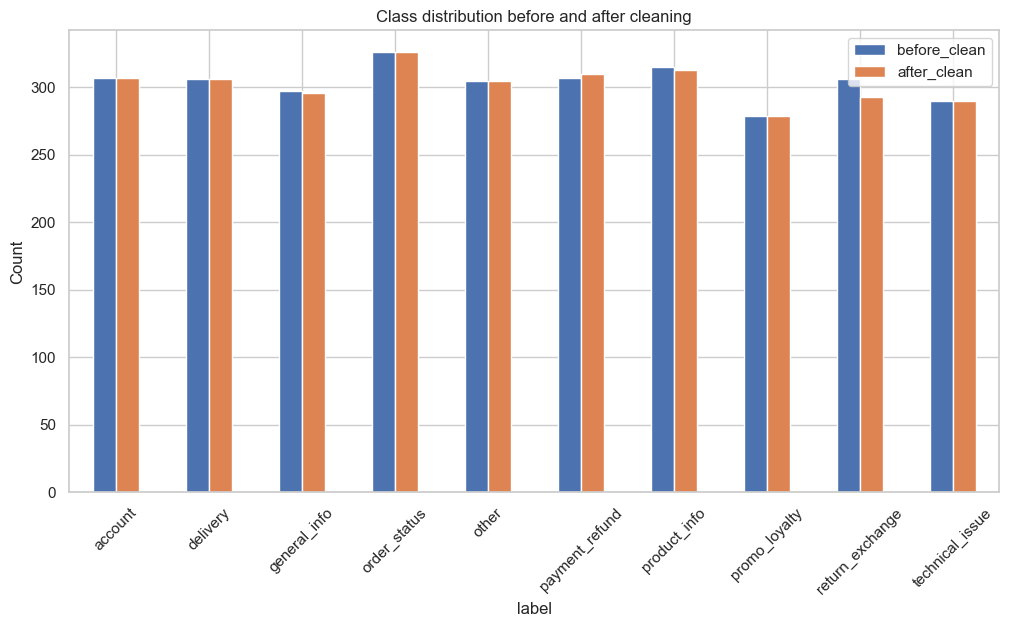

In [5]:
comparison[["before_clean", "after_clean"]].plot(kind="bar")
plt.title("Class distribution before and after cleaning")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Exact duplicates and conflicting labels

In [6]:
exact_original = pd.read_csv(review_dir / "exact_duplicates_original.csv")
exact_normalized = pd.read_csv(review_dir / "exact_duplicates_normalized.csv")
conflicting_labels = pd.read_csv(review_dir / "conflicting_labels_same_text.csv")

print("exact_original:", exact_original.shape)
print("exact_normalized:", exact_normalized.shape)
print("conflicting_labels:", conflicting_labels.shape)

exact_original: (0, 9)
exact_normalized: (0, 9)
conflicting_labels: (0, 9)


Вывод: точных дубликатов и конфликтов одинаковых нормализованных текстов не выявлено.

## Аудит класса `other`

In [7]:
other_audit = pd.read_csv(review_dir / "other_class_audit.csv")
other_audit["other_subtype_rule"].value_counts()

other_subtype_rule
feedback_complaint    129
operator_contact       80
unclassified           56
legal_claim            40
Name: count, dtype: int64

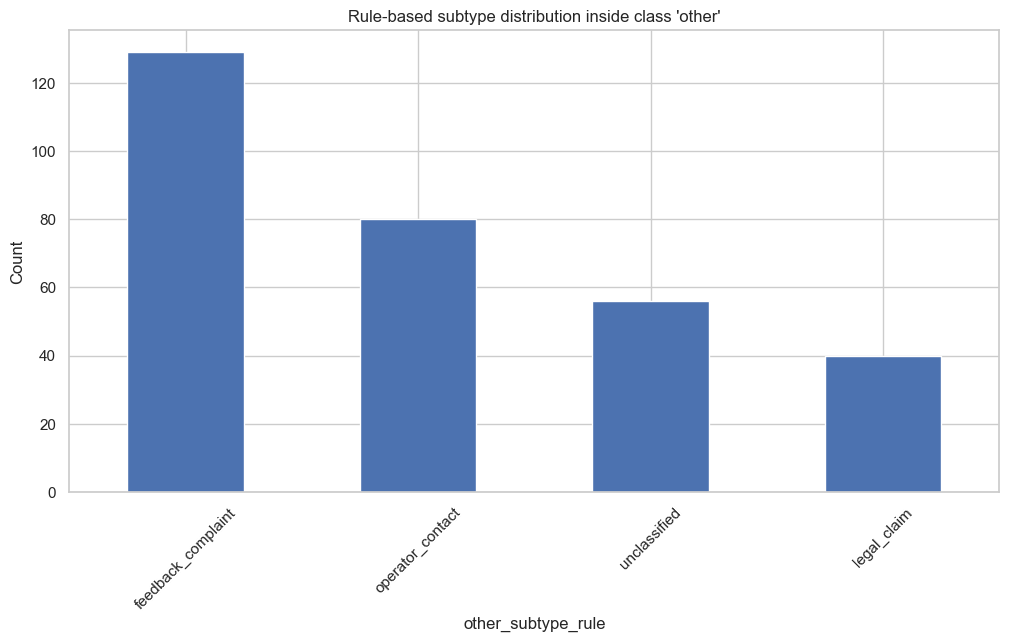

In [8]:
other_audit["other_subtype_rule"].value_counts().plot(kind="bar")
plt.title("Rule-based subtype distribution inside class 'other'")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Вывод: класс `other` не является off-topic классом в чистом виде. Основную часть составляют:
- feedback / complaint,
- operator contact,
- legal claim.

На этапе 1 класс сохранён как отдельный интент без изменения числа классов. Его дальнейшая декомпозиция отложена до этапа error analysis классификатора.

## Near-duplicates analysis

In [9]:
near_duplicates = pd.read_csv(review_dir / "near_duplicates.csv")
near_duplicates.shape

(19846, 10)

In [10]:
near_duplicates["same_label"].value_counts()

same_label
True     18333
False     1513
Name: count, dtype: int64

In [11]:
near_duplicates[["label_1", "label_2", "same_label"]].value_counts().head(20)

label_1          label_2          same_label
promo_loyalty    promo_loyalty    True          6079
technical_issue  technical_issue  True          5220
general_info     general_info     True          1785
return_exchange  return_exchange  True          1457
product_info     product_info     True           954
other            other            True           801
delivery         delivery         True           712
account          account          True           483
payment_refund   payment_refund   True           424
order_status     order_status     True           418
product_info     return_exchange  False          192
                 other            False          146
                 promo_loyalty    False          123
general_info     promo_loyalty    False           90
return_exchange  payment_refund   False           82
order_status     return_exchange  False           72
product_info     delivery         False           70
                 general_info     False           63
r

Вывод: анализ near-duplicates показал высокую степень шаблонности датасета, особенно в классах `promo_loyalty` и `technical_issue`.

## Suspicious cross-class pairs

In [12]:
cross_pairs = pd.read_csv(review_dir / "cross_class_suspicious_pairs.csv")
print(cross_pairs.shape)
cross_pairs[["label_1", "label_2"]].value_counts().head(20)

(2593, 9)


label_1          label_2        
other            product_info       120
                 general_info       104
return_exchange  product_info        94
technical_issue  product_info        90
payment_refund   return_exchange     89
promo_loyalty    product_info        85
return_exchange  order_status        85
product_info     return_exchange     82
promo_loyalty    delivery            81
general_info     delivery            77
technical_issue  account             76
order_status     return_exchange     75
product_info     other               71
delivery         order_status        68
return_exchange  payment_refund      64
account          technical_issue     58
general_info     other               55
payment_refund   order_status        53
order_status     payment_refund      52
                 delivery            47
Name: count, dtype: int64

Наиболее проблемные межклассовые пересечения наблюдаются между:
- `payment_refund` ↔ `return_exchange`
- `general_info` ↔ `product_info`
- `other` ↔ `product_info`
- `technical_issue` ↔ `account`
- `delivery` ↔ `order_status`

## Manual borderline review

In [13]:
manual_review = pd.read_csv(review_dir / "manual_borderline_review.csv")
manual_review["decision"].value_counts()

decision
hard_negative    25
drop_2            7
relabel_1         7
relabel_2         5
drop_1            3
drop_both         3
Name: count, dtype: int64

In [14]:
manual_review.groupby("target_pair")["decision"].value_counts()

target_pair                      decision     
general_info__product_info       hard_negative    22
                                 drop_both         2
                                 relabel_1         1
payment_refund__return_exchange  drop_2            7
                                 relabel_1         6
                                 relabel_2         5
                                 drop_1            3
                                 hard_negative     3
                                 drop_both         1
Name: count, dtype: int64

Ручная ревизия включала 50 пограничных пар:
- 25 для `payment_refund` ↔ `return_exchange`
- 25 для `general_info` ↔ `product_info`

In [15]:
with open(reports_dir / "stage1_manual_review_apply_summary.json", "r", encoding="utf-8") as f:
    manual_apply_summary = json.load(f)

manual_apply_summary

{'base_dataset_path': 'ml\\data\\processed\\full_dataset_stage1_base.csv',
 'review_path': 'ml\\data\\interim\\review\\manual_borderline_review.csv',
 'base_rows': 3038,
 'reviewed_pairs': 50,
 'review_decision_counts': {'keep': 0,
  'relabel_1': 7,
  'relabel_2': 5,
  'drop_1': 3,
  'drop_2': 7,
  'drop_both': 3,
  'hard_negative': 25},
 'relabeled_samples': 11,
 'dropped_unique_sample_ids': 13,
 'dropped_rows_in_dataset': 13,
 'hard_negative_pairs_saved': 25,
 'clean_dataset_rows': 3025,
 'output_dataset_path': 'ml\\data\\processed\\full_dataset_stage1_clean.csv',
 'output_hard_negative_path': 'ml\\data\\interim\\review\\hard_negative_pairs_from_review.csv'}

Ключевые результаты:
- переразмечено 11 примеров;
- удалено 13 примеров;
- выделено 25 hard-negative пар;
- итоговый очищенный датасет содержит 3025 записей.

In [16]:
with open(reports_dir / "stage1_clean_splits_check.json", "r", encoding="utf-8") as f:
    clean_split_report = json.load(f)

clean_split_report

{'sizes': {'train_clean': 2117, 'val': 454, 'test': 454},
 'nulls': {'train_clean': {'text_original_nulls': 0,
   'text_normalized_nulls': 0,
   'label_nulls': 0},
  'val': {'text_original_nulls': 0,
   'text_normalized_nulls': 0,
   'label_nulls': 0},
  'test': {'text_original_nulls': 0,
   'text_normalized_nulls': 0,
   'label_nulls': 0}},
 'all_classes_present': True,
 'augmented_flags_clean': True,
 'hard_negative_flags_clean': True,
 'intersections': {'train_clean__val': {'same_sample_id': 0,
   'same_text_normalized': 0},
  'train_clean__test': {'same_sample_id': 0, 'same_text_normalized': 0},
  'val__test': {'same_sample_id': 0, 'same_text_normalized': 0}},
 'status': 'PASS'}

Clean splits построены корректно:
- train_clean: 2117
- val: 454
- test: 454

Проверка целостности завершилась со статусом PASS.

In [17]:
hn_only = pd.read_csv(BASE_DIR / "data/splits/stage1/train_hard_negatives_only.csv")
print(hn_only.shape)
hn_only["label"].value_counts().sort_index()

(25, 14)


label
general_info       15
payment_refund      2
product_info        7
return_exchange     1
Name: count, dtype: int64

На этапе 1 hard-negatives добавлены в train в пилотном объёме. Дальнейшее расширение hard-negatives будет выполняться после error analysis обученного классификатора.

In [18]:
with open(reports_dir / "stage1_train_augmentation_summary.json", "r", encoding="utf-8") as f:
    aug_summary = json.load(f)

aug_summary

{'seed': 42,
 'target_per_class': 520,
 'train_rows_before': 2142,
 'augmented_rows_added': 3058,
 'train_rows_after': 5200,
 'class_added_counter': {'account': 305,
  'delivery': 306,
  'general_info': 297,
  'order_status': 292,
  'other': 307,
  'payment_refund': 301,
  'product_info': 294,
  'promo_loyalty': 325,
  'return_exchange': 314,
  'technical_issue': 317},
 'augmentation_method_counter': {'phrase_compression': 296,
  'punctuation_variant': 713,
  'typo_delete_char': 649,
  'typo_duplicate_char': 758,
  'typo_swap_adjacent': 642},
 'final_distribution': {'account': 520,
  'delivery': 520,
  'general_info': 520,
  'order_status': 520,
  'other': 520,
  'payment_refund': 520,
  'product_info': 520,
  'promo_loyalty': 520,
  'return_exchange': 520,
  'technical_issue': 520},
 'output_aug_only_path': 'ml\\data\\splits\\stage1\\train_augmented_only.csv',
 'output_train_final_path': 'ml\\data\\splits\\stage1\\train_augmented.csv'}

In [19]:
df_train_aug["label"].value_counts().sort_index()

label
account            520
delivery           520
general_info       520
order_status       520
other              520
payment_refund     520
product_info       520
promo_loyalty      520
return_exchange    520
technical_issue    520
Name: count, dtype: int64

In [20]:
df_train_aug_only["augmentation_method"].value_counts()

augmentation_method
typo_duplicate_char    758
punctuation_variant    713
typo_delete_char       649
typo_swap_adjacent     642
phrase_compression     296
Name: count, dtype: int64

Аугментация применялась только к train. Для каждого класса итоговый размер train был доведён до 520 примеров.

In [21]:
print("val is_augmented:", df_val["is_augmented"].value_counts().to_dict())
print("val is_hard_negative:", df_val["is_hard_negative"].value_counts().to_dict())

print("test is_augmented:", df_test["is_augmented"].value_counts().to_dict())
print("test is_hard_negative:", df_test["is_hard_negative"].value_counts().to_dict())

val is_augmented: {False: 454}
val is_hard_negative: {False: 454}
test is_augmented: {False: 454}
test is_hard_negative: {False: 454}


Validation и test выборки остались чистыми:
- без аугментации;
- без hard-negatives;
- без утечек из train.

## Итог

На Этапе 1 выполнены:
- сборка Stage 1 base dataset;
- анализ exact duplicates;
- анализ near-duplicates;
- анализ suspicious cross-class pairs;
- аудит класса `other`;
- ручная ревизия 50 пограничных пар;
- очистка и переразметка датасета;
- сборка clean train/val/test;
- добавление hard-negatives только в train;
- аугментация train до 520 примеров на класс.

### Ограничения
- hard-negatives на текущем этапе добавлены в пилотном объёме;
- дальнейшее расширение hard-negatives будет выполняться после анализа ошибок классификатора;
- класс `other` требует дальнейшей семантической декомпозиции на последующих этапах.